In [0]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [0]:
# Load your cleaned data
df = pd.read_csv("/Volumes/airfly_workspace/default/airfly_insights/flights_cleaned.csv")

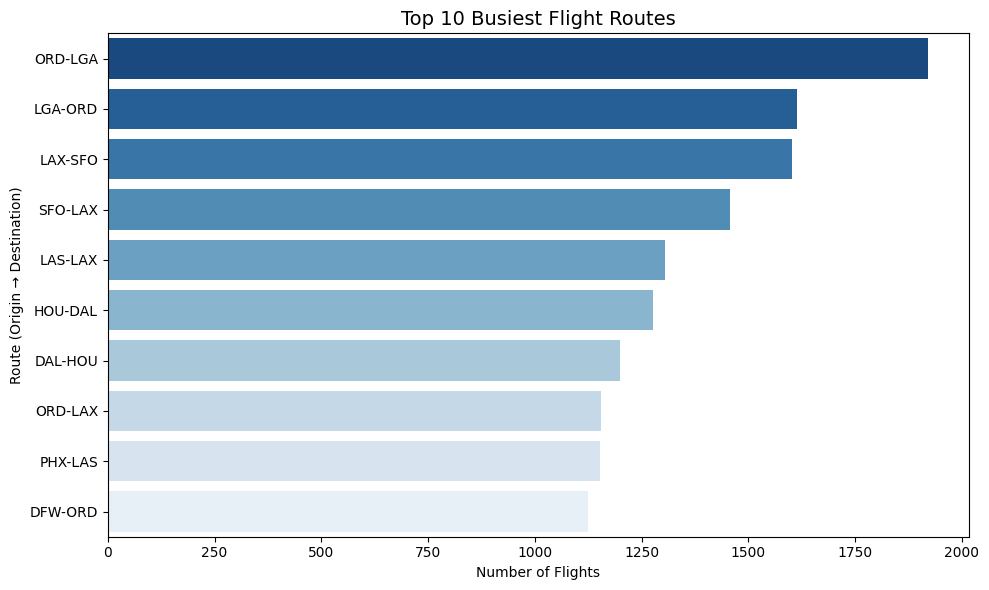

In [0]:
# Top 10 Origin–Destination Pairs (Most Frequent Routes)

route_freq = df['Route'].value_counts().head(10).reset_index()
route_freq.columns = ['Route', 'Flight_Count']

plt.figure(figsize=(10,6))
sns.barplot(x='Flight_Count', y='Route', data=route_freq, palette='Blues_r')
plt.title('Top 10 Busiest Flight Routes', fontsize=14)
plt.xlabel('Number of Flights')
plt.ylabel('Route (Origin → Destination)')
plt.tight_layout()
plt.show()

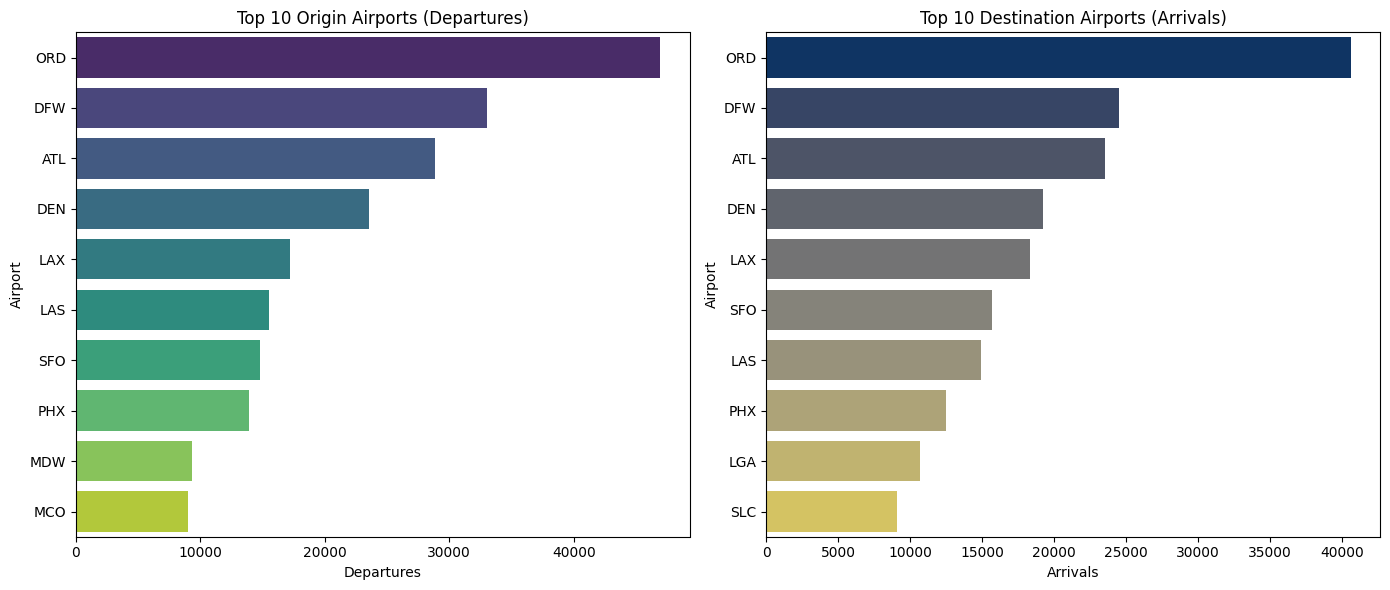

In [0]:
# Airport-Wise Flight Volume (Top Origin & Destination Airports)

origin_count = df['Origin'].value_counts().head(10).reset_index()
dest_count = df['Dest'].value_counts().head(10).reset_index()

origin_count.columns = ['Airport', 'Departures']
dest_count.columns = ['Airport', 'Arrivals']

# Plot side-by-side comparison
fig, axes = plt.subplots(1,2, figsize=(14,6))
sns.barplot(x='Departures', y='Airport', data=origin_count, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Origin Airports (Departures)')

sns.barplot(x='Arrivals', y='Airport', data=dest_count, ax=axes[1], palette='cividis')
axes[1].set_title('Top 10 Destination Airports (Arrivals)')

plt.tight_layout()
plt.show()


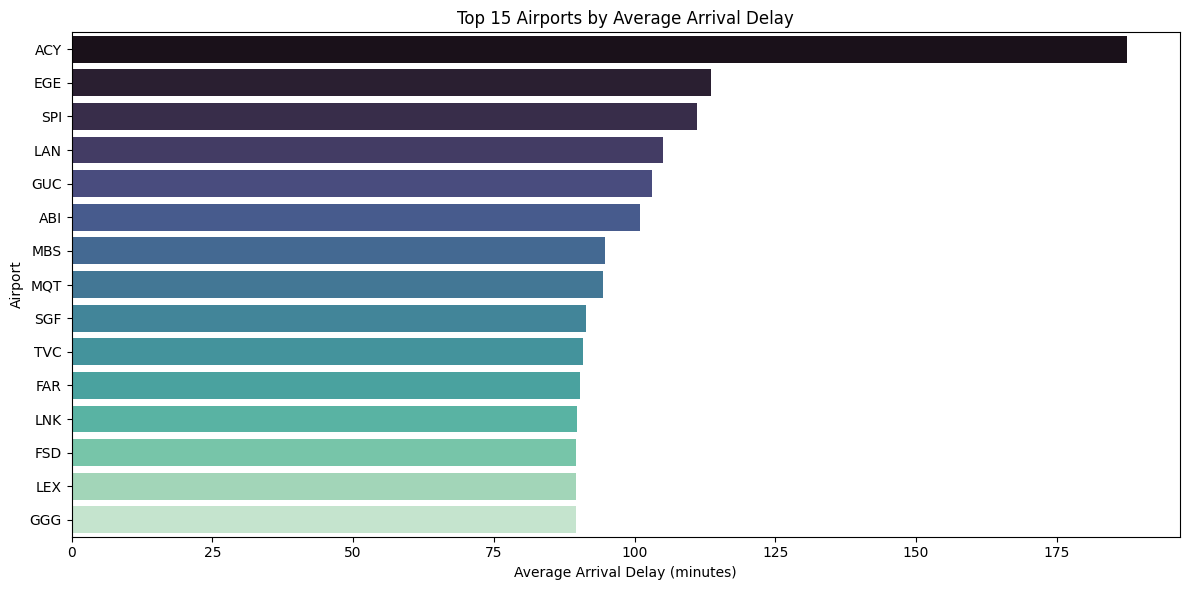

In [0]:
# Average Delay by Airport

airport_delay = df.groupby('Origin')['ArrDelay'].mean().reset_index().sort_values(by='ArrDelay', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='ArrDelay', y='Origin', data=airport_delay.head(15), palette='mako')
plt.title('Top 15 Airports by Average Arrival Delay')
plt.xlabel('Average Arrival Delay (minutes)')
plt.ylabel('Airport')
plt.tight_layout()
plt.show()


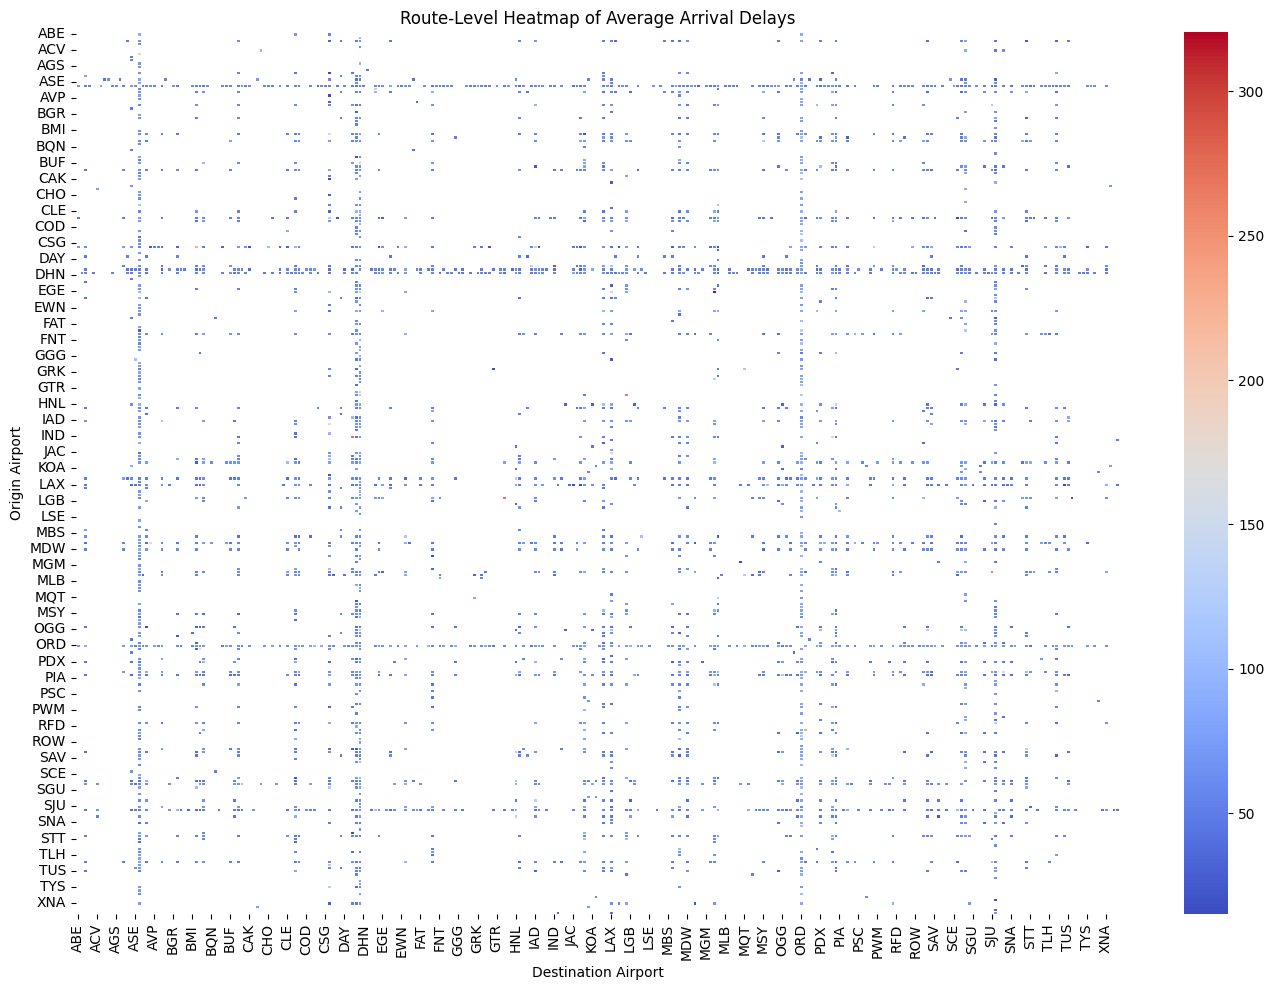

In [0]:
# Delay Heatmap by Origin–Destination Route

route_delay = df.pivot_table(values='ArrDelay', index='Origin', columns='Dest', aggfunc='mean')

plt.figure(figsize=(14,10))
sns.heatmap(route_delay, cmap='coolwarm', linewidths=0.5)
plt.title('Route-Level Heatmap of Average Arrival Delays')
plt.xlabel('Destination Airport')
plt.ylabel('Origin Airport')
plt.tight_layout()
plt.show()


In [0]:
# Geographic Visualization – Busiest Airports and Average Delay Map

df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load("/Volumes/airfly_workspace/default/airfly_insights/flights_cleaned.csv"))
    
unique_airports = [row['Origin'] for row in df.select('Origin').distinct().collect()]

import numpy as np
coords = {a: (np.random.uniform(25, 49), np.random.uniform(-125, -67)) for a in unique_airports}

import pandas as pd
coords_df = pd.DataFrame([
    {'Origin': k, 'Latitude': v[0], 'Longitude': v[1]} for k, v in coords.items()
])

coords_sdf = spark.createDataFrame(coords_df)
df_with_coords = df.join(coords_sdf, on='Origin', how='left')

from pyspark.sql.functions import mean, count
airport_stats = df_with_coords.groupBy(
    'Origin', 'Latitude', 'Longitude'
).agg(
    mean('ArrDelay').alias('Avg_Delay'),
    count('Route').alias('Flight_Count')
)

airport_stats_pd = airport_stats.toPandas()

import plotly.express as px
fig = px.scatter_geo(
    airport_stats_pd,
    lat='Latitude',
    lon='Longitude',
    hover_name='Origin',
    size='Flight_Count',
    color='Avg_Delay',
    color_continuous_scale='Reds',
    projection='natural earth',
    title='Busiest Airports and Average Delays (Simulated Coordinates)'
)
fig.show()

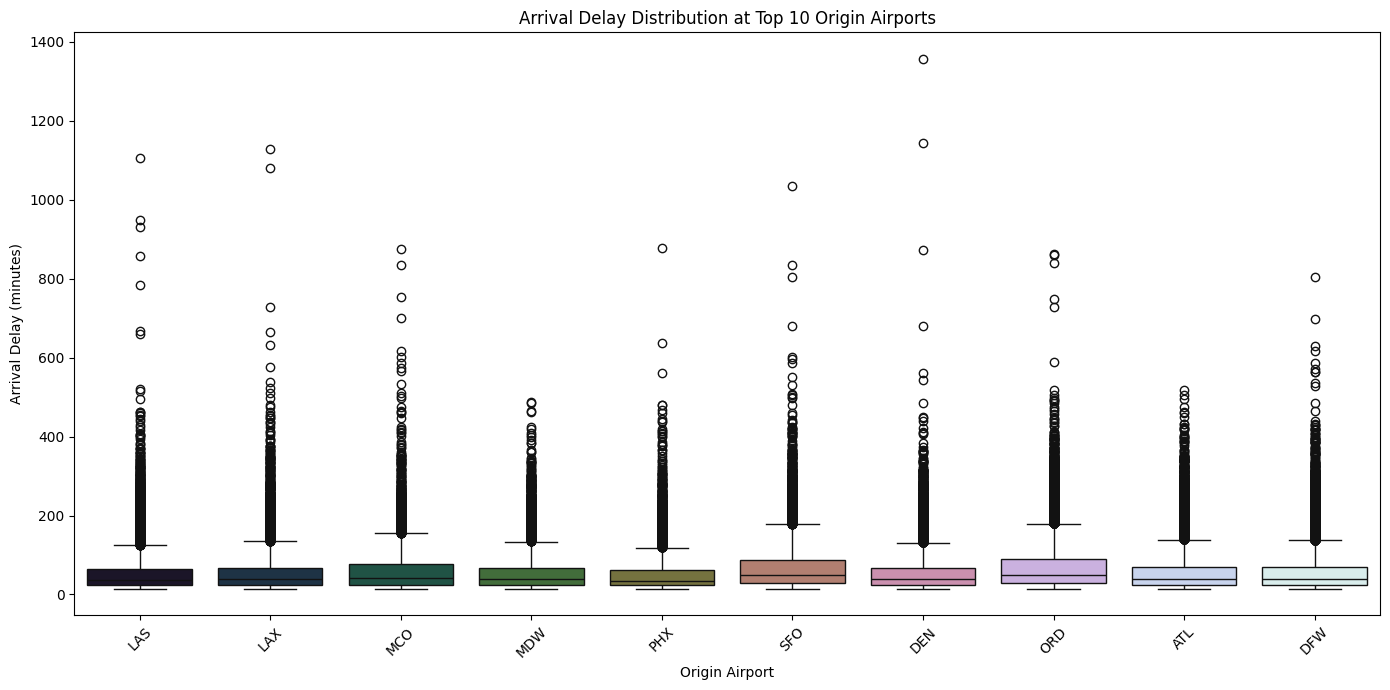

In [0]:
# Delay Distribution per Airport

plt.figure(figsize=(14,7))
top_airports = df['Origin'].value_counts().head(10).index
sns.boxplot(x='Origin', y='ArrDelay', data=df[df['Origin'].isin(top_airports)], palette='cubehelix')
plt.title('Arrival Delay Distribution at Top 10 Origin Airports')
plt.xlabel('Origin Airport')
plt.ylabel('Arrival Delay (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

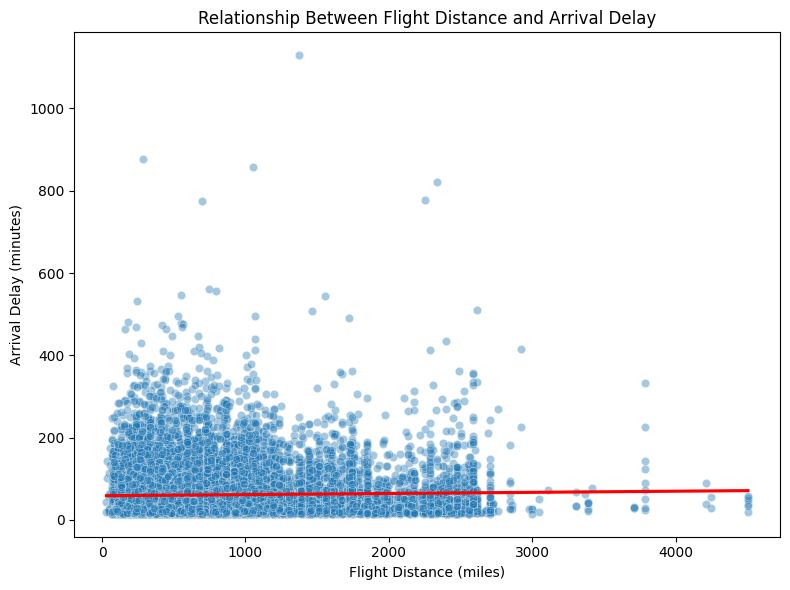

In [0]:
# Correlation Between Distance and Arrival Delay

plt.figure(figsize=(8,6))
sns.scatterplot(x='Distance', y='ArrDelay', data=df.sample(20000), alpha=0.4)
sns.regplot(x='Distance', y='ArrDelay', data=df, scatter=False, color='red')
plt.title('Relationship Between Flight Distance and Arrival Delay')
plt.xlabel('Flight Distance (miles)')
plt.ylabel('Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

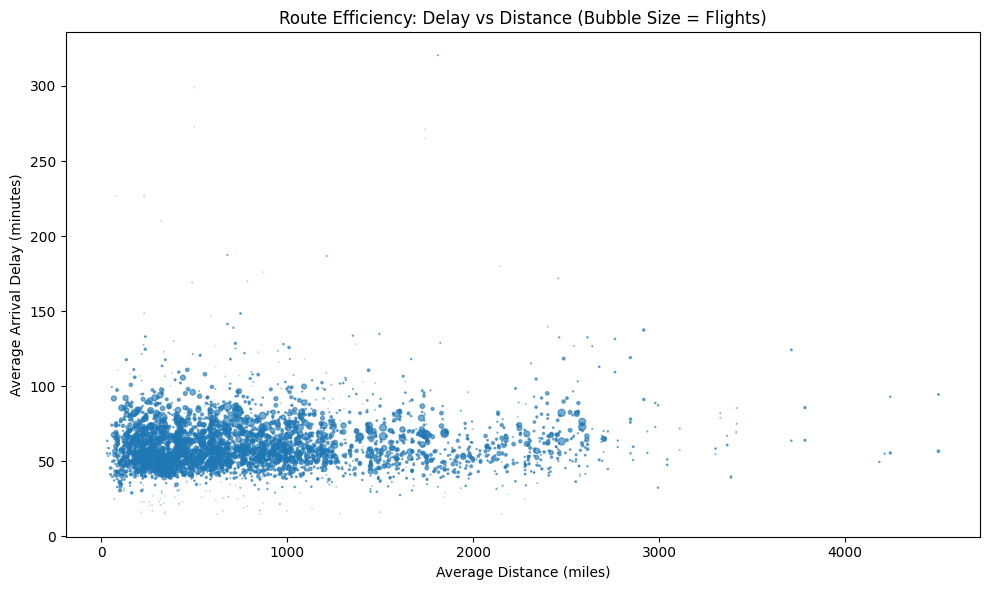

In [0]:
# Route Efficiency (Bubble Chart)

route_eff = df.groupby('Route').agg({'ArrDelay':'mean','Distance':'mean','Route':'count'})
route_eff.rename(columns={'Route':'Count'}, inplace=True)

plt.figure(figsize=(10,6))
plt.scatter(route_eff['Distance'], route_eff['ArrDelay'],
            s=route_eff['Count']/30, alpha=0.6)
plt.title('Route Efficiency: Delay vs Distance (Bubble Size = Flights)')
plt.xlabel('Average Distance (miles)')
plt.ylabel('Average Arrival Delay (minutes)')
plt.tight_layout()
plt.show()

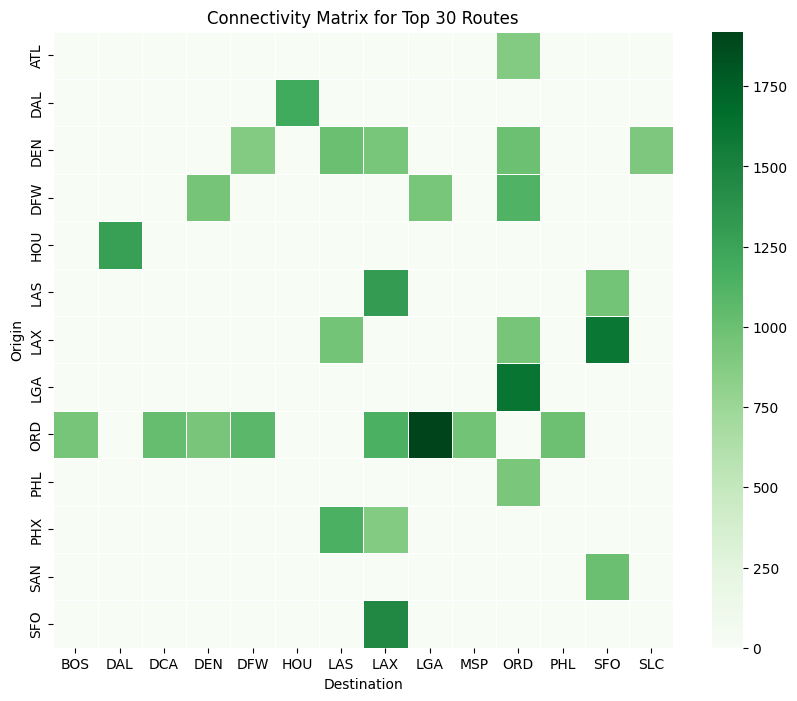

In [0]:
# Airport Connectivity Network (Chord/Heat) Approximation

top_routes = df['Route'].value_counts().head(30).index
net = df[df['Route'].isin(top_routes)]
route_matrix = pd.crosstab(net['Origin'], net['Dest'])

plt.figure(figsize=(10,8))
sns.heatmap(route_matrix, cmap='Greens', linewidths=0.5)
plt.title('Connectivity Matrix for Top 30 Routes')
plt.xlabel('Destination')
plt.ylabel('Origin')
plt.show()

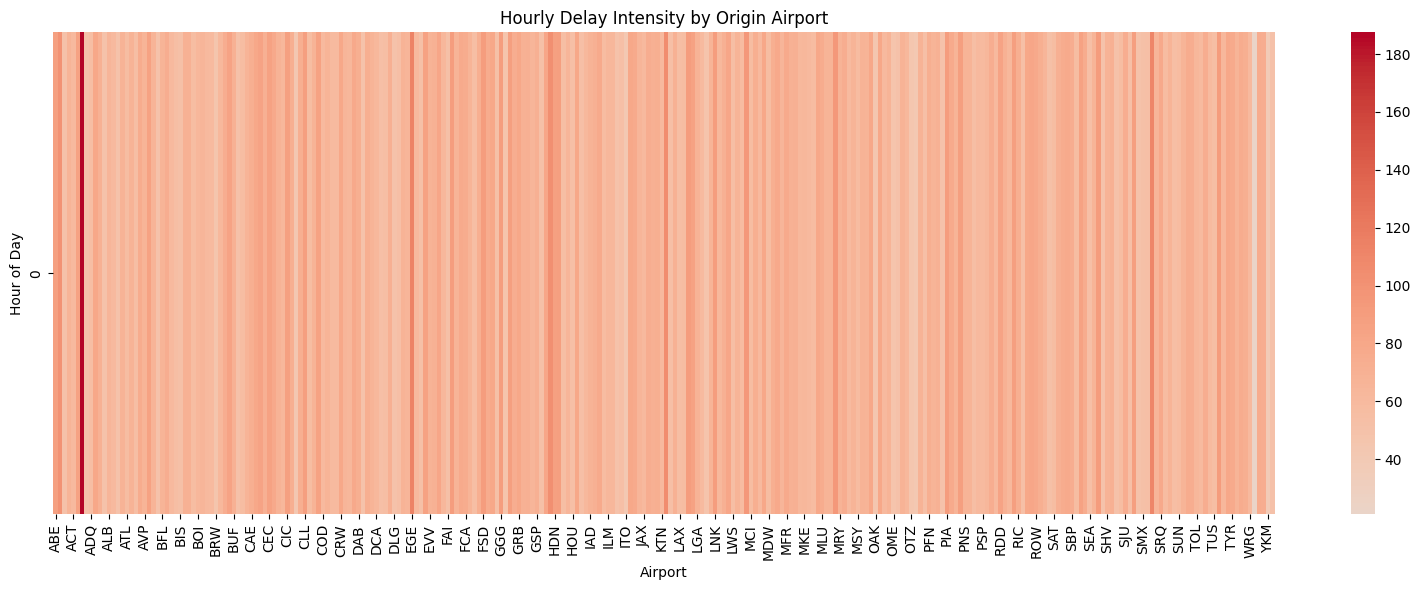

In [0]:
# Delay Intensity Heatmap on Time vs Airport

df['Hour'] = pd.to_datetime(df['Date']).dt.hour
heat_data = df.pivot_table(values='ArrDelay', index='Hour', columns='Origin', aggfunc='mean')

plt.figure(figsize=(16,6))
sns.heatmap(heat_data, cmap='coolwarm', center=0)
plt.title('Hourly Delay Intensity by Origin Airport')
plt.xlabel('Airport')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()


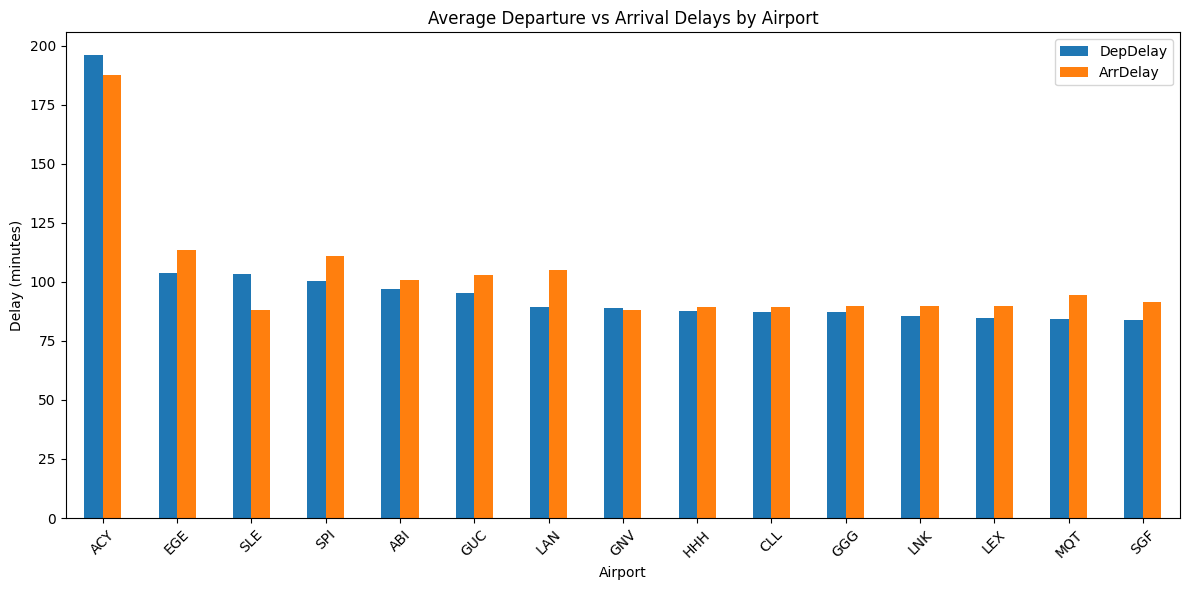

In [0]:
# Departure vs Arrival Delay Comparison by Airport

compare = df.groupby('Origin')[['DepDelay','ArrDelay']].mean().sort_values('DepDelay',ascending=False).head(15)
compare.plot(kind='bar', figsize=(12,6))
plt.title('Average Departure vs Arrival Delays by Airport')
plt.xlabel('Airport')
plt.ylabel('Delay (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()